# DeltaSnow Calibration — Results Overview

Visualises `opt_results_summary.csv` across all weight combinations, datasets, and optimisers.

| § | Plot | What it shows |
|---|------|----------------|
| 0 | Data snapshot | Quick stats and sample rows |
| 1 | Score heatmap | Best value per weight combo × dataset × algorithm |
| 2 | **Score vs each weight** | How each individual weight drives the calibration score |
| 3 | DE vs Nelder-Mead | Head-to-head on identical setups |
| 4 | Weight sweep | Score as SWE ↔ density ratio shifts (w_BIAS = 0) |
| 5 | Parameter dot plot | All calibrated values, Cleveland-style |
| 6 | Density params vs error | ρ_max & ρ_null: where each run lands |
| 7 | Best-run summary | Top configuration per dataset × algorithm |
| 8 | Score distribution | Box + strip plot across all weight configs |

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.lines import Line2D
from IPython.display import display
import warnings; warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
import sys, os; sys.path.insert(0, '/Users/jakobwerkgarner/code/mt_dsnow')
from plot_style import apply_style, C, ALPHA, LS, HATCH, SUBSET_COLOR, dataset_color, build_palette
apply_style()
plt.rcParams.update({'figure.dpi': 130})

# ── Paths ─────────────────────────────────────────────────────────────────────
CSV_PATH  = "/Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/below2000/res/opt_results_summary_b2000.csv"
PLOTS_DIR = '/Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/below2000/plots'

# ── Weight columns & labels ───────────────────────────────────────────────────
WEIGHT_COLS = ['w_SWE_NRMSE', 'w_RHO_NRMSE', 'w_SWE_NBIAS',
               'w_RHO_NBIAS', 'w_SWE_KGE',   'w_RHO_KGE']
W_LABELS = {
    'w_SWE_NRMSE': 'w(SWE NRMSE)',
    'w_RHO_NRMSE': 'w(ρ NRMSE)',
    'w_SWE_NBIAS': 'w(SWE NBIAS)',
    'w_RHO_NBIAS': 'w(ρ NBIAS)',
    'w_SWE_KGE':   'w(SWE KGE)',
    'w_RHO_KGE':   'w(ρ KGE)',
}

# ── Phase labels ──────────────────────────────────────────────────────────────
# Key: (w_SWE_NRMSE, w_RHO_NRMSE, w_SWE_NBIAS, w_RHO_NBIAS, w_SWE_KGE, w_RHO_KGE)
# rounded to 3 dp to absorb float noise.
PHASE_LABELS = {
    (1.0,  0.0,  0.0,  0.0,  0.0,  0.0): "1A — SWE-only",
    (0.0,  1.0,  0.0,  0.0,  0.0,  0.0): "1B — Density-only",
    (0.7,  0.3,  0.0,  0.0,  0.0,  0.0): "2A — SWE-dom. (0.7/0.3)",
    (0.5,  0.5,  0.0,  0.0,  0.0,  0.0): "2B — Equal (0.5/0.5)",
    (0.3,  0.7,  0.0,  0.0,  0.0,  0.0): "2C — Density-dom. (0.3/0.7)",
    (0.6,  0.2,  0.2,  0.0,  0.0,  0.0): "3A — Bal.+SWE bias (0.6/0.2/0.2)",
    (0.7,  0.0,  0.3,  0.0,  0.0,  0.0): "3B — SWE-dom.+SWE bias (0.7/0.0/0.3)",
    (0.3,  0.5,  0.2,  0.0,  0.0,  0.0): "3C — Dens-dom.+SWE bias (0.3/0.5/0.2)",
    (0.6,  0.2,  0.0,  0.2,  0.0,  0.0): "4A — Bal.+ρ bias (0.6/0.2/0.2)",
    (0.7,  0.1,  0.0,  0.2,  0.0,  0.0): "4B — SWE-dom.+ρ bias (0.7/0.1/0.2)",
    (0.3,  0.5,  0.0,  0.2,  0.0,  0.0): "4C — Dens-dom.+ρ bias (0.3/0.5/0.2)",
    (0.4,  0.4,  0.1,  0.1,  0.0,  0.0): "5A — Bal.+both bias (0.4/0.4/0.1/0.1)",
    (0.8,  0.1,  0.05, 0.05, 0.0,  0.0): "5B — SWE-dom.+both bias (0.8/0.1/0.05)",
    (0.1,  0.8,  0.05, 0.05, 0.0,  0.0): "5C — Dens-dom.+both bias (0.1/0.8/0.05)",
    (0.25, 0.25, 0.25, 0.25, 0.0,  0.0): "5D — Bias-focused (0.25×4)",
    (0.0,  0.0,  0.5,  0.5,  0.0,  0.0): "5E — Bias-only (0.5/0.5)",
    (0.0,  0.5,  0.0,  0.0,  0.5,  0.0): "6A — KGE-SWE + NRMSE-ρ",
    (0.5,  0.0,  0.0,  0.0,  0.0,  0.5): "6B — NRMSE-SWE + KGE-ρ",
    (0.0,  0.0,  0.0,  0.0,  1.0,  0.0): "6C — KGE-SWE only",
    (0.0,  0.0,  0.0,  0.0,  0.0,  1.0): "6D — KGE-ρ only",
}

# ── Parameter metadata ────────────────────────────────────────────────────────
PAR_META = {
    'rho_max':  dict(lo=300,   hi=600,   default=401.26, label='ρ_max',  unit='kg m⁻³', log=False),
    'rho_null': dict(lo=60,    hi=150,   default=81.19,  label='ρ_null', unit='kg m⁻³', log=False),
    'eta_null': dict(lo=1e5,   hi=1e8,   default=8.52e6, label='η_null', unit='Pa s',             log=True),
    'k':        dict(lo=0.001, hi=0.1,   default=0.03,   label='k',           unit='day⁻¹',  log=True),
    'tau':      dict(lo=0.001, hi=0.1,   default=0.024,  label='τ',      unit='day',               log=True),
    'c_ov':     dict(lo=1e-6,  hi=0.01,  default=5.1e-4, label='c_ov',        unit='m² kg⁻¹', log=True),
    'k_ov':     dict(lo=0.01,  hi=1.0,   default=0.379,  label='k_ov',        unit='—',            log=False),
}
PAR_COLS = list(PAR_META.keys())

# ── Colour / marker palette ───────────────────────────────────────────────────
PALETTE = build_palette(['SNOWPACK', 'Win21'])
MARKERS = {'DE': 'o', 'Nelder-Mead': 's'}
ALG_HATCH = {'DE': HATCH.DE, 'Nelder-Mead': HATCH.NM}  # bar/patch hatch per optimizer

def legend_handles(datasets, algs=('DE', 'Nelder-Mead')):
    return [
        Line2D([0],[0], color=PALETTE.get(ds,'#888'), marker=MARKERS[a],
               ls='None', markersize=7, label=f'{ds} {a}')
        for ds in datasets for a in algs if a in MARKERS
    ]

print('Setup complete.')

Setup complete.


In [28]:
# -- Load (schema-tolerant for old/new summary CSV layouts) ------------------
df = pd.read_csv(CSV_PATH, na_values=['NA'])

# Accept legacy names from older collectors.
legacy_cols = {
    'SWE_NRMSE': 'w_SWE_NRMSE',
    'RHO_NRMSE': 'w_RHO_NRMSE',
    'SWE_NBIAS': 'w_SWE_NBIAS',
    'RHO_NBIAS': 'w_RHO_NBIAS',
    'SWE_KGE': 'w_SWE_KGE',
    'RHO_KGE': 'w_RHO_KGE',
    'rho.max': 'rho_max',
    'rho.null': 'rho_null',
    'eta.null': 'eta_null',
    'c.ov': 'c_ov',
    'k.ov': 'k_ov',
}
rename_map = {k: v for k, v in legacy_cols.items() if k in df.columns and v not in df.columns}
if rename_map:
    df = df.rename(columns=rename_map)

# Ensure required columns exist and are numeric where expected.
for col in WEIGHT_COLS:
    if col not in df.columns:
        df[col] = 0.0
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)

for col in PAR_COLS:
    if col not in df.columns:
        df[col] = np.nan
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in ['best_value', 'iterations'] :
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

def _infer_dataset(path):
    s = str(path)
    if 'calibration_Win21' in s or '/Win21/' in s:
        return 'Win21'
    if 'calibration_SNOWPACK' in s or '/SNOWPACK/' in s:
        return 'SNOWPACK'
    return np.nan

def _infer_algorithm(path):
    s = str(path)
    b = s.split('/')[-1]
    if 'R_opt_logs_DE' in s or b.startswith('opt_results_DE') or '_DE__' in b:
        return 'DE'
    if 'R_opt_logs/' in s or b.startswith('opt_results__'):
        return 'Nelder-Mead'
    return np.nan

if 'dataset' not in df.columns:
    df['dataset'] = np.nan
if 'algorithm' not in df.columns:
    df['algorithm'] = np.nan

if 'source_path' in df.columns:
    df['dataset'] = df['dataset'].fillna(df['source_path'].map(_infer_dataset))
    df['algorithm'] = df['algorithm'].fillna(df['source_path'].map(_infer_algorithm))

df['dataset'] = df['dataset'].fillna('SNOWPACK')
df['algorithm'] = (
    df['algorithm']
    .replace({'NM': 'Nelder-Mead', 'optim': 'Nelder-Mead'})
    .fillna('Unknown')
)

sort_cols = WEIGHT_COLS + ['dataset', 'algorithm']
df = df.sort_values(sort_cols).reset_index(drop=True)

# -- Phase label ---------------------------------------------------------------
def get_phase(row):
    key = tuple(round(float(row[c]), 3) for c in WEIGHT_COLS)
    return PHASE_LABELS.get(key, '')   # '' for unrecognised combos
df['phase'] = df.apply(get_phase, axis=1)

# Weight-combo label: use phase name when available, else list non-zero weights
def wlabel(row):
    if row['phase']:
        return row['phase']
    parts = [f"{c[2:]}={row[c]:.2g}" for c in WEIGHT_COLS if row[c] > 0]
    return ', '.join(parts) if parts else 'all-zero'
df['wlabel'] = df.apply(wlabel, axis=1)

# Short y-axis label: "Phase 2A — SWE-dom. | SNOWPACK DE"
# Falls back to weight triplet if no phase name matched.
def run_label(row):
    alg = 'DE' if row['algorithm'] == 'DE' else 'NM'
    if row['phase']:
        return f"{row['phase']}  |  {row['dataset']} {alg}"
    w3 = (f"{row['w_SWE_NRMSE']:.2g}/"
          f"{row['w_RHO_NRMSE']:.2g}/"
          f"{row['w_SWE_NBIAS']:.2g}")
    return f"{row['dataset']} {alg} ({w3})"
df['run_label'] = df.apply(run_label, axis=1)

# Small x-jitter so stacked points separate visually
rng = np.random.default_rng(42)
df['_jx'] = rng.uniform(-0.018, 0.018, len(df))

_valid = df['best_value'].notna()
DATASETS = sorted(df['dataset'].unique())
ALGS     = sorted(df['algorithm'].dropna().unique())

print(f"Runs total  : {len(df):>4d}")
print(f"  valid score : {_valid.sum()}")
print(f"  NA score    : {(~_valid).sum()}")
print(f"Datasets    : {DATASETS}")
print(f"Algorithms  : {ALGS}")
print(f"Phase-labelled: {(df['phase'] != '').sum()}  |  unlabelled: {(df['phase'] == '').sum()}")
df[['dataset','algorithm','phase','wlabel','best_value']].head(8)

Runs total  :   40
  valid score : 40
  NA score    : 0
Datasets    : ['SNOWPACK']
Algorithms  : ['DE', 'Nelder-Mead']
Phase-labelled: 40  |  unlabelled: 0


,dataset,algorithm,phase,wlabel,best_value
0,SNOWPACK,DE,6D — KGE-ρ only,6D — KGE-ρ only,0.1589
1,SNOWPACK,Nelder-Mead,6D — KGE-ρ only,6D — KGE-ρ only,0.1679
2,SNOWPACK,DE,6C — KGE-SWE only,6C — KGE-SWE only,0.01331
3,SNOWPACK,Nelder-Mead,6C — KGE-SWE only,6C — KGE-SWE only,0.01214
4,SNOWPACK,DE,5E — Bias-only (0.5/0.5),5E — Bias-only (0.5/0.5),0.001295
5,SNOWPACK,Nelder-Mead,5E — Bias-only (0.5/0.5),5E — Bias-only (0.5/0.5),1.72e-06
6,SNOWPACK,DE,6A — KGE-SWE + NRMSE-ρ,6A — KGE-SWE + NRMSE-ρ,0.09765
7,SNOWPACK,Nelder-Mead,6A — KGE-SWE + NRMSE-ρ,6A — KGE-SWE + NRMSE-ρ,0.09786


---
## § 0 — Data Snapshot

In [29]:
summary = (
    df.groupby(['dataset', 'algorithm'])
    .agg(
        n_runs        = ('best_value', 'count'),
        n_na          = ('best_value', lambda x: x.isna().sum()),
        score_min     = ('best_value', 'min'),
        score_median  = ('best_value', 'median'),
        score_max     = ('best_value', 'max'),
    )
    .reset_index()
)
summary.columns = ['Dataset','Algorithm','Runs (valid)','Runs (NA)',
                   'Score min','Score median','Score max']
pd.set_option('display.float_format', lambda x: f'{x:.5g}')
display(summary)

,Dataset,Algorithm,Runs (valid),Runs (NA),Score min,Score median,Score max
0,SNOWPACK,DE,20,0,0.0012948,0.16904,0.21957
1,SNOWPACK,Nelder-Mead,20,0,1.72e-06,0.17184,0.22531


---
## § 1 — Score Heatmap
Each cell shows the optimised objective score (lower = better).  
Rows = weight combinations, columns = dataset × algorithm.

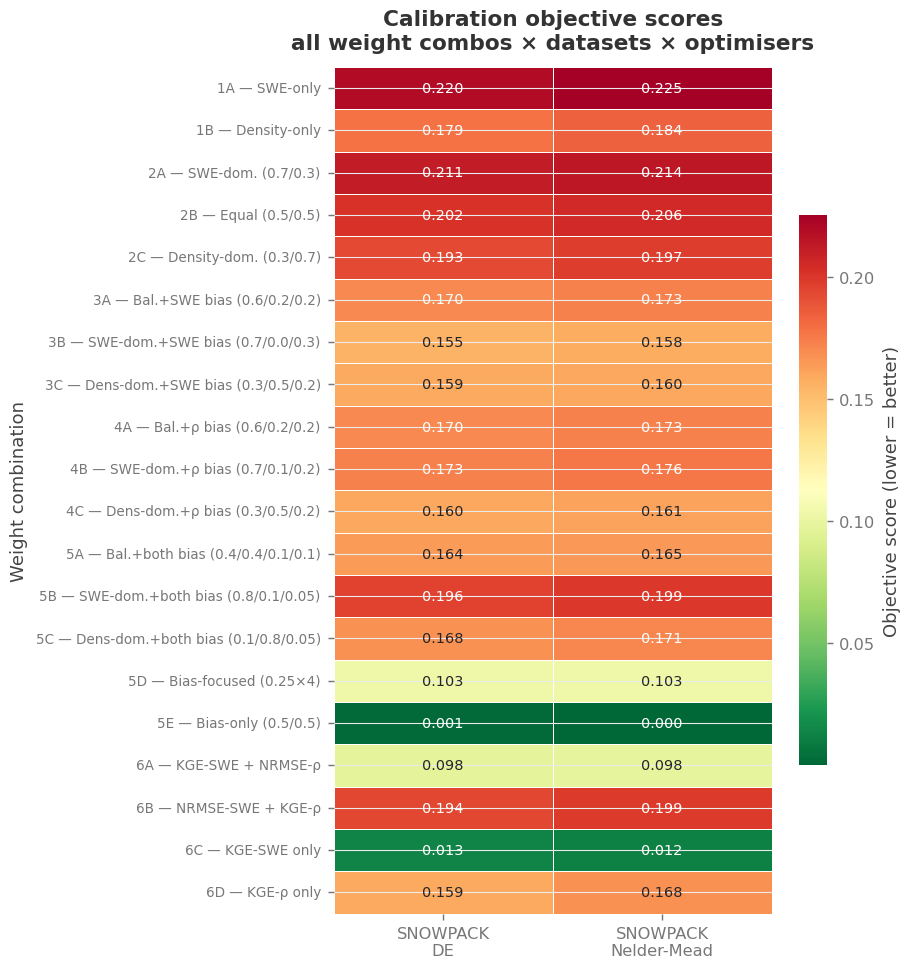

In [30]:
df['run_col'] = df['dataset'] + '\n' + df['algorithm']
col_order = [f'{ds}\n{a}' for ds in DATASETS for a in ALGS
             if f'{ds}\n{a}' in df['run_col'].values]

pivot = df.pivot_table(index='wlabel', columns='run_col',
                       values='best_value', aggfunc='first')
pivot = pivot.reindex(columns=[c for c in col_order if c in pivot.columns])

fig, ax = plt.subplots(figsize=(max(7, len(pivot.columns)*2.2),
                                max(5, len(pivot)*0.38)))
sns.heatmap(
    pivot, ax=ax,
    cmap='RdYlGn_r',
    annot=True, fmt='.3f', annot_kws={'size': 8},
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Objective score (lower = better)', 'shrink': 0.65}
)
ax.set_xlabel('')
ax.set_ylabel('Weight combination')
ax.set_title('Calibration objective scores\nall weight combos × datasets × optimisers',
             fontweight='bold', pad=10)
ax.tick_params(axis='y', labelsize=7.5)
ax.tick_params(axis='x', labelsize=9)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_score_heatmap.png', bbox_inches='tight')
plt.show()

---
## § 2 — Score vs Each Weight Metric
Six scatter panels — one per weight metric.  
**x** = weight value assigned to that metric (0 → 1)  
**y** = best optimised objective score  
**colour** = dataset · **shape** = algorithm  

Points at the same x are jittered horizontally.  
Dashed lines = linear trends per dataset.

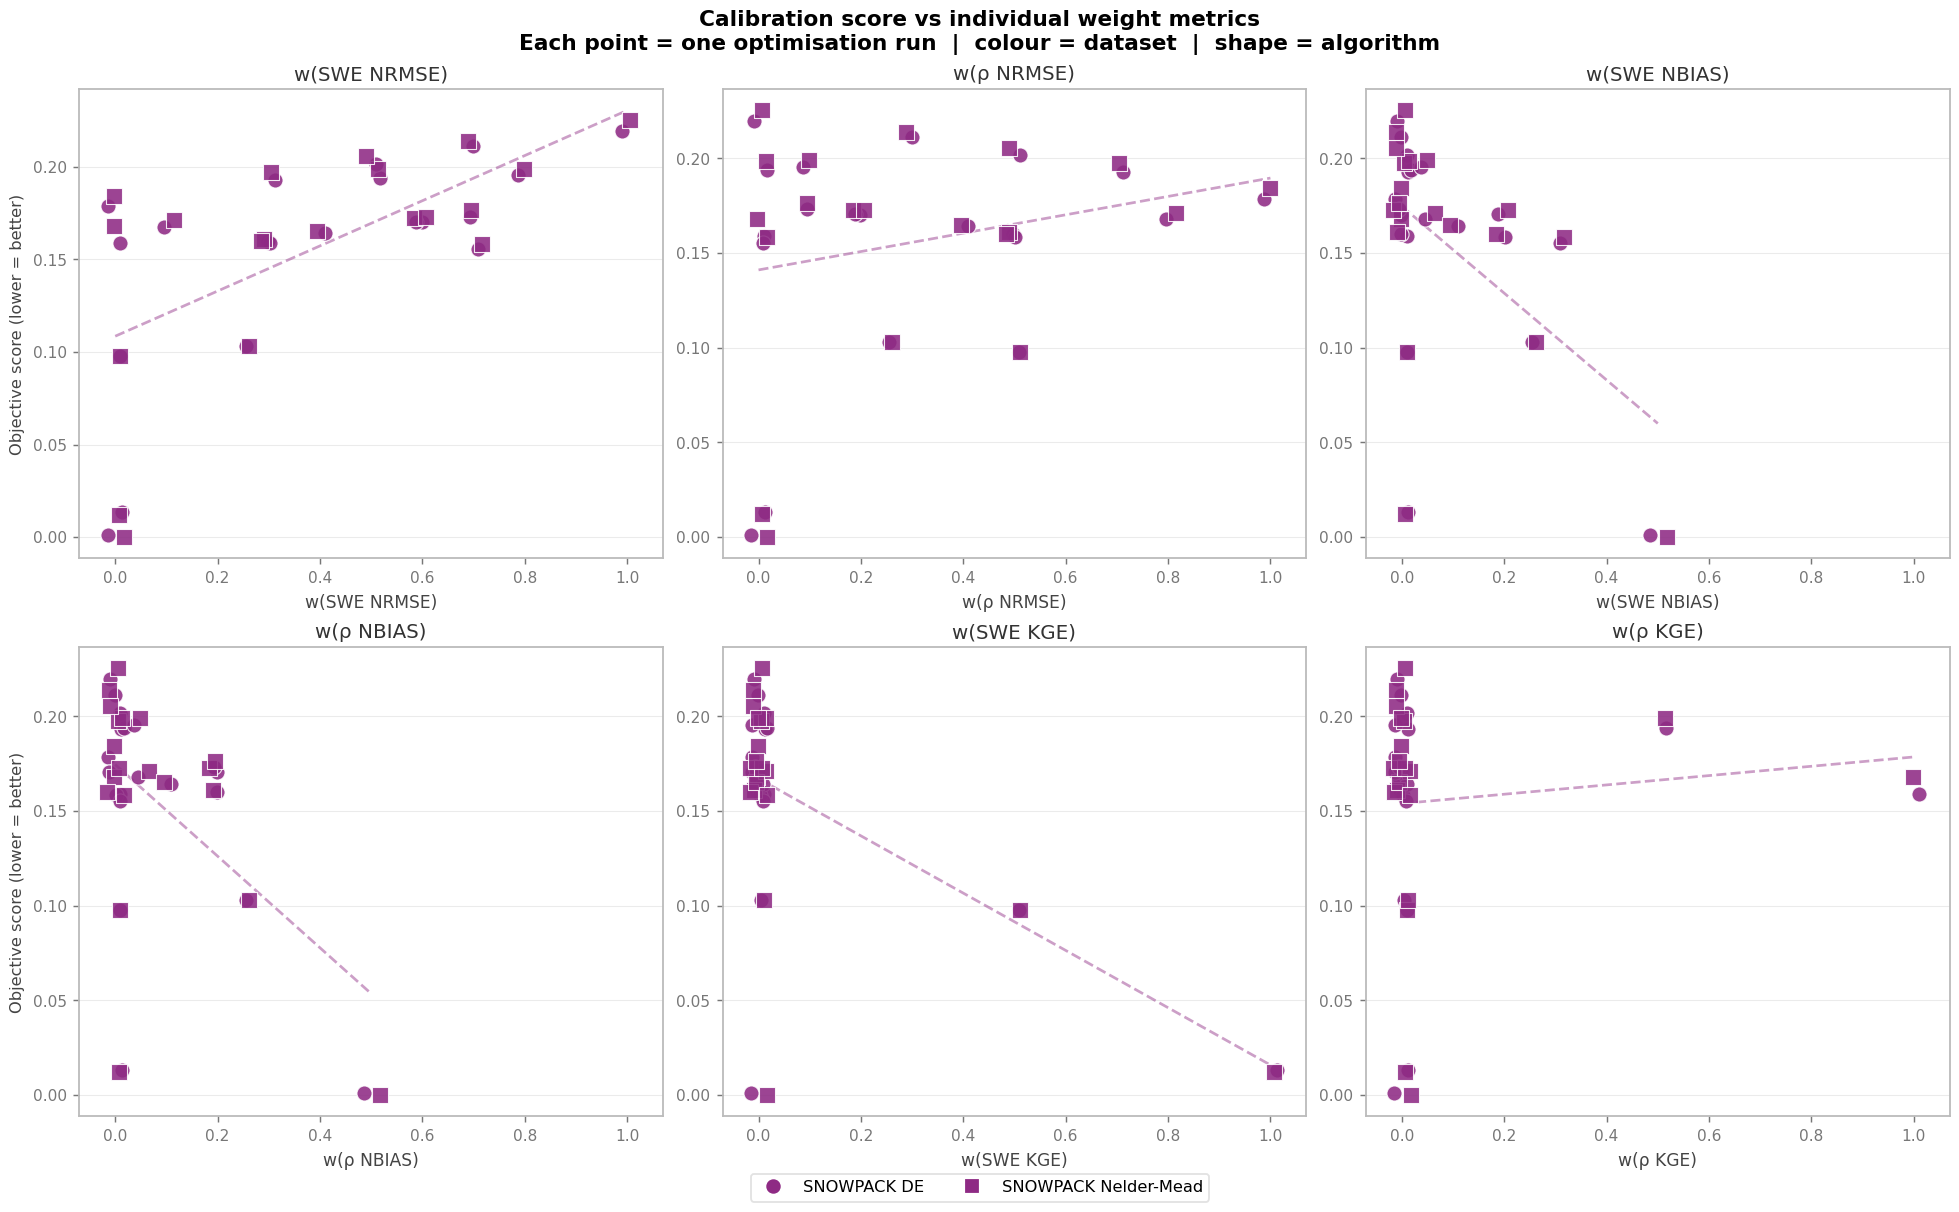

In [31]:
valid = df.dropna(subset=['best_value']).copy()

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
fig.suptitle('Calibration score vs individual weight metrics\n'
             'Each point = one optimisation run  |  colour = dataset  |  shape = algorithm',
             fontsize=12, fontweight='bold')

for ax, wcol in zip(axes.flat, WEIGHT_COLS):
    ax.set_title(W_LABELS[wcol], fontsize=11, pad=5)

    # ── Scatter ───────────────────────────────────────────────────────────
    for ds in DATASETS:
        for alg in ALGS:
            sub = valid[(valid['dataset'] == ds) & (valid['algorithm'] == alg)]
            if sub.empty: continue
            ax.scatter(
                sub[wcol] + sub['_jx'], sub['best_value'],
                color=PALETTE.get(ds, '#888'),
                marker=MARKERS.get(alg, 'o'),
                s=70, alpha=0.88,
                edgecolors='white', linewidths=0.6, zorder=3
            )

    # ── Linear trend per dataset ──────────────────────────────────────────
    for ds in DATASETS:
        sub = valid[valid['dataset'] == ds].sort_values(wcol)
        xs, ys = sub[wcol].values, sub['best_value'].values
        mask = np.isfinite(ys)
        if mask.sum() >= 4 and len(np.unique(xs[mask])) >= 3:
            try:
                z    = np.polyfit(xs[mask], ys[mask], 1)
                xfit = np.linspace(xs[mask].min(), xs[mask].max(), 60)
                ax.plot(xfit, np.polyval(z, xfit),
                        color=PALETTE.get(ds, '#888'),
                        lw=1.5, ls='--', alpha=0.45, zorder=2)
            except Exception:
                pass

    ax.set_xlim(-0.07, 1.07)
    ax.set_xlabel(W_LABELS[wcol], fontsize=9.5)
    if ax in axes[:, 0]:
        ax.set_ylabel('Objective score (lower = better)', fontsize=9)
    ax.tick_params(labelsize=8.5)

# Shared legend
fig.legend(
    handles=legend_handles(DATASETS, ALGS),
    loc='lower center', ncol=len(DATASETS)*len(ALGS),
    fontsize=9, bbox_to_anchor=(0.5, -0.03)
)
plt.savefig(f'{PLOTS_DIR}/02_score_vs_weights.png', bbox_inches='tight')
plt.show()

---
## § 3 — DE vs Nelder-Mead: Head-to-head
Each point = one *(dataset, weight combo)* pair run with both algorithms.  
Points **above** the diagonal → Nelder-Mead wins; **below** → DE wins.

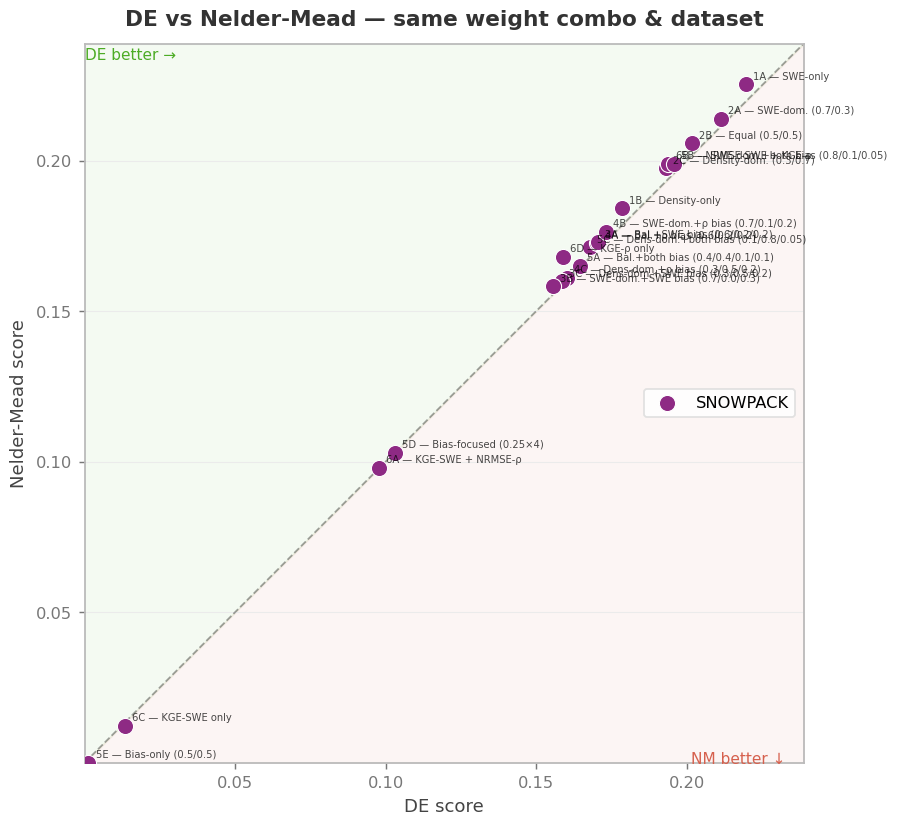

In [32]:
de  = df[df['algorithm']=='DE'][['dataset','wlabel','phase','best_value']].rename(columns={'best_value':'score_DE'})
nm  = df[df['algorithm']=='Nelder-Mead'][['dataset','wlabel','phase','best_value']].rename(columns={'best_value':'score_NM'})
cmp = de.merge(nm, on=['dataset','wlabel'], suffixes=('','_nm')).dropna(subset=['score_DE','score_NM'])
# keep one 'phase' column
cmp['phase'] = cmp['phase'].fillna(cmp.get('phase_nm',''))

if cmp.empty:
    print('No matched DE/NM pairs found — skipping plot.')
else:
    lim_lo = cmp[['score_DE','score_NM']].min().min() * 0.90
    lim_hi = cmp[['score_DE','score_NM']].max().max() * 1.06

    fig, ax = plt.subplots(figsize=(7, 6.5))
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, alpha=0.35)

    for ds, grp in cmp.groupby('dataset'):
        ax.scatter(
            grp['score_DE'], grp['score_NM'],
            color=PALETTE.get(ds,'#888'), s=80, zorder=3,
            edgecolors='white', linewidths=0.6, label=ds
        )
        for _, row in grp.iterrows():
            lbl = row['phase'] if row['phase'] else row['wlabel']
            ax.annotate(
                lbl, (row['score_DE'], row['score_NM']),
                fontsize=5.5, ha='left', va='bottom',
                xytext=(4, 2), textcoords='offset points', alpha=0.72
            )

    ax.fill_between([lim_lo, lim_hi], [lim_lo, lim_lo], [lim_lo, lim_hi],
                    alpha=0.06, color='#d6604d')
    ax.fill_between([lim_lo, lim_hi], [lim_lo, lim_hi], [lim_hi, lim_hi],
                    alpha=0.06, color='#4dac26')
    ax.text(lim_hi * 0.975, lim_lo * 1.02, 'NM better ↓',
            ha='right', fontsize=8.5, color='#d6604d')
    ax.text(lim_lo * 1.02, lim_hi * 0.978, 'DE better →',
            ha='left',  fontsize=8.5, color='#4dac26')

    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_xlabel('DE score', fontsize=10)
    ax.set_ylabel('Nelder-Mead score', fontsize=10)
    ax.set_title('DE vs Nelder-Mead — same weight combo & dataset',
                 fontweight='bold', pad=10)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/03_DE_vs_NM.png', bbox_inches='tight')
    plt.show()

---
## § 5 — Calibrated Parameters: Cleveland Dot Plot
Every dot = one run. **Grey band** = optimisation bounds. **Dashed line** = pydeltasnow default.

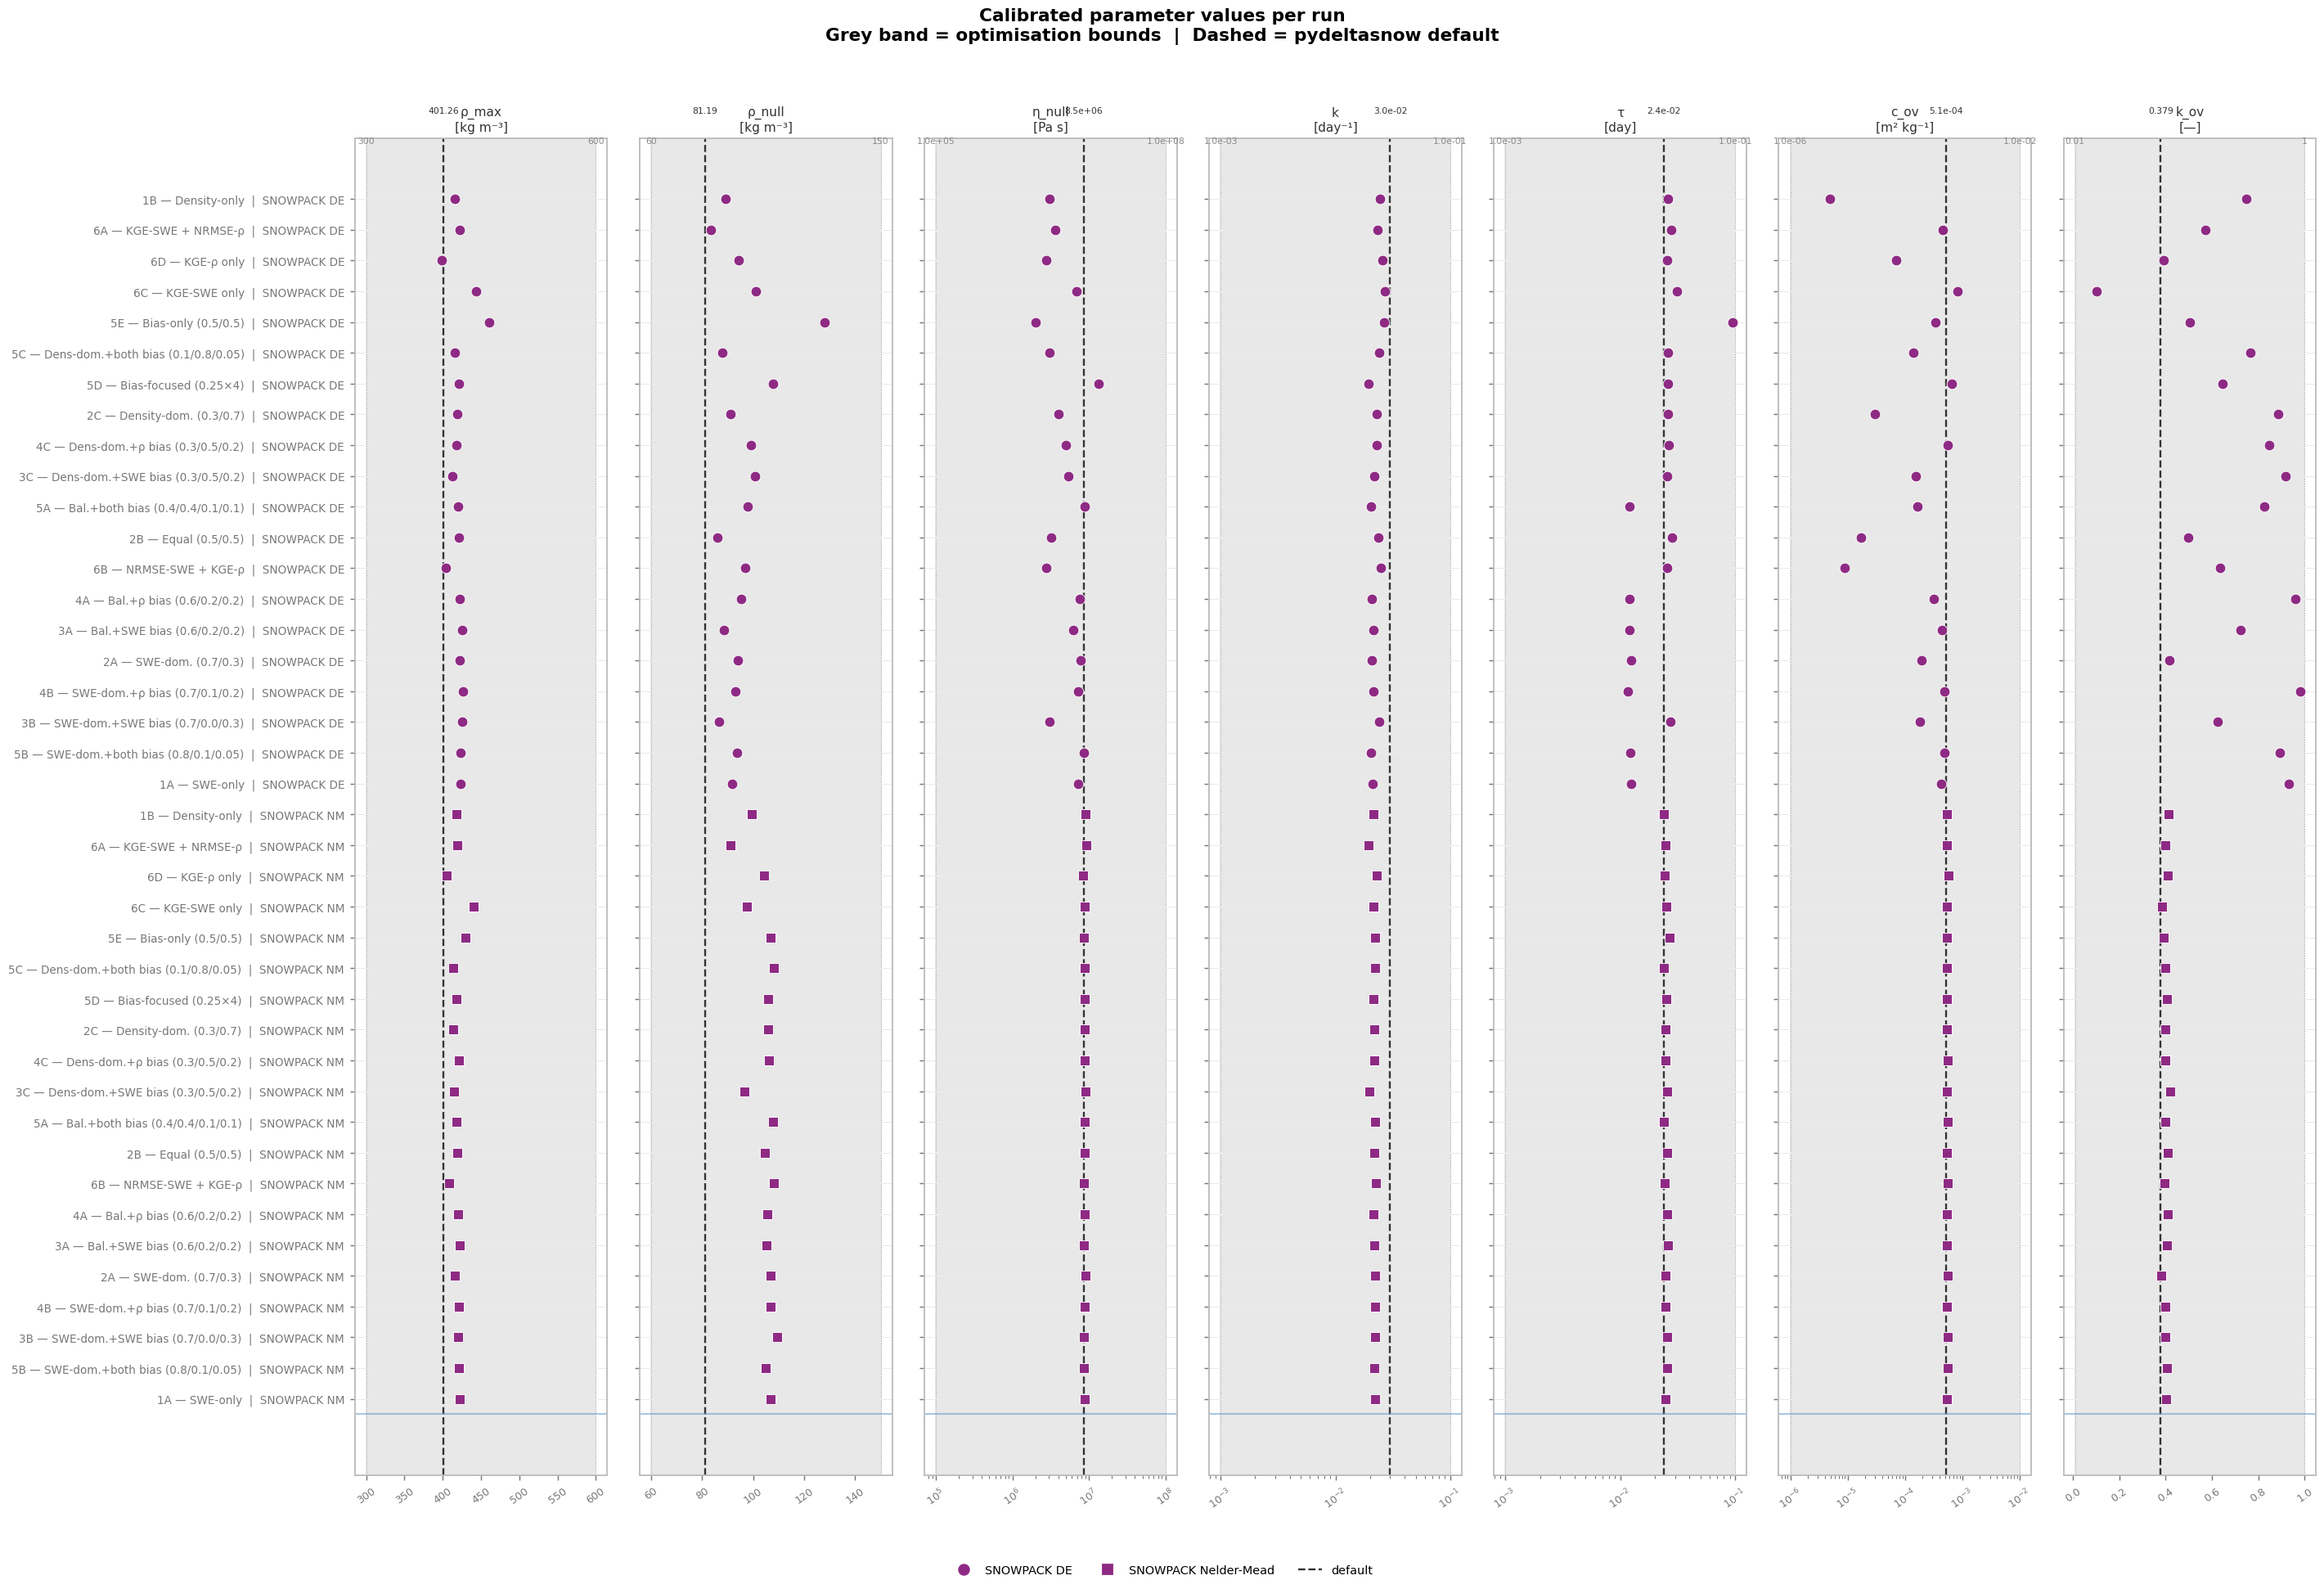

In [33]:
df_s = df.sort_values(
    ['dataset', 'algorithm', 'w_SWE_NRMSE', 'w_RHO_NRMSE'],
    ascending=[False, True, True, False]
).reset_index(drop=True)

y_labels = df_s['run_label'].tolist()
y_pos    = np.arange(len(y_labels))
n_snow   = (df_s['dataset'] == 'SNOWPACK').sum()

fig, axes = plt.subplots(1, len(PAR_COLS), figsize=(22, max(6, len(y_labels)*0.35)), sharey=True)
fig.suptitle(
    'Calibrated parameter values per run\n'
    'Grey band = optimisation bounds  |  Dashed = pydeltasnow default',
    fontweight='bold', fontsize=12, y=1.02
)

for ax, par in zip(axes, PAR_COLS):
    meta = PAR_META[par]

    # Grey band + bound lines
    ax.axvspan(meta['lo'], meta['hi'], color='#e8e8e8', zorder=0)
    ax.axvline(meta['lo'],      color='#aaa', lw=0.6, ls=':',  zorder=1)
    ax.axvline(meta['hi'],      color='#aaa', lw=0.6, ls=':',  zorder=1)
    ax.axvline(meta['default'], color='#333', lw=1.3, ls='--', zorder=2)

    # Horizontal guide lines
    for yi in y_pos:
        ax.axhline(yi, color='#e0e0e0', lw=0.4, zorder=0)

    # Dataset / algorithm divider
    ax.axhline(n_snow - 0.5, color='#5591c8', lw=1.2, ls='-', alpha=0.5)

    # Dots
    for yi, (_, row) in zip(y_pos, df_s.iterrows()):
        val = row[par]
        if not np.isfinite(float(val if pd.notna(val) else np.nan)): continue
        ax.scatter(val, yi,
                   color=PALETTE.get(row['dataset'],'#888'),
                   marker=MARKERS.get(row['algorithm'],'o'),
                   s=50, zorder=3, edgecolors='white', linewidths=0.5)

    if meta['log']:
        ax.set_xscale('log')
    ax.set_title(f"{meta['label']}\n[{meta['unit']}]", fontsize=8.5, pad=5)
    ax.tick_params(axis='x', labelsize=7, rotation=35)

    # Physical unit annotations at top
    fmt = lambda v: f'{v:.1e}' if meta['log'] else f'{v:g}'
    ax.text(meta['lo'],      -1.8, fmt(meta['lo']),      ha='center', fontsize=6, color='#888')
    ax.text(meta['hi'],      -1.8, fmt(meta['hi']),      ha='center', fontsize=6, color='#888')
    ax.text(meta['default'], -2.8, fmt(meta['default']), ha='center', fontsize=6, color='#333')

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(y_labels, fontsize=7.5)
axes[0].invert_yaxis()

fig.legend(
    handles=legend_handles(DATASETS, ALGS) + [
        Line2D([0],[0], color='#333', lw=1.3, ls='--', label='default')
    ],
    loc='lower center', ncol=len(DATASETS)*len(ALGS)+1,
    fontsize=8, bbox_to_anchor=(0.5, -0.04), frameon=False
)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_parameter_cleveland.png', bbox_inches='tight')
plt.show()

---
## § 7 — Density Parameters vs Calibration Error
Three panels: ρ_max vs score · ρ_null vs score · ρ_max vs ρ_null coloured by score.

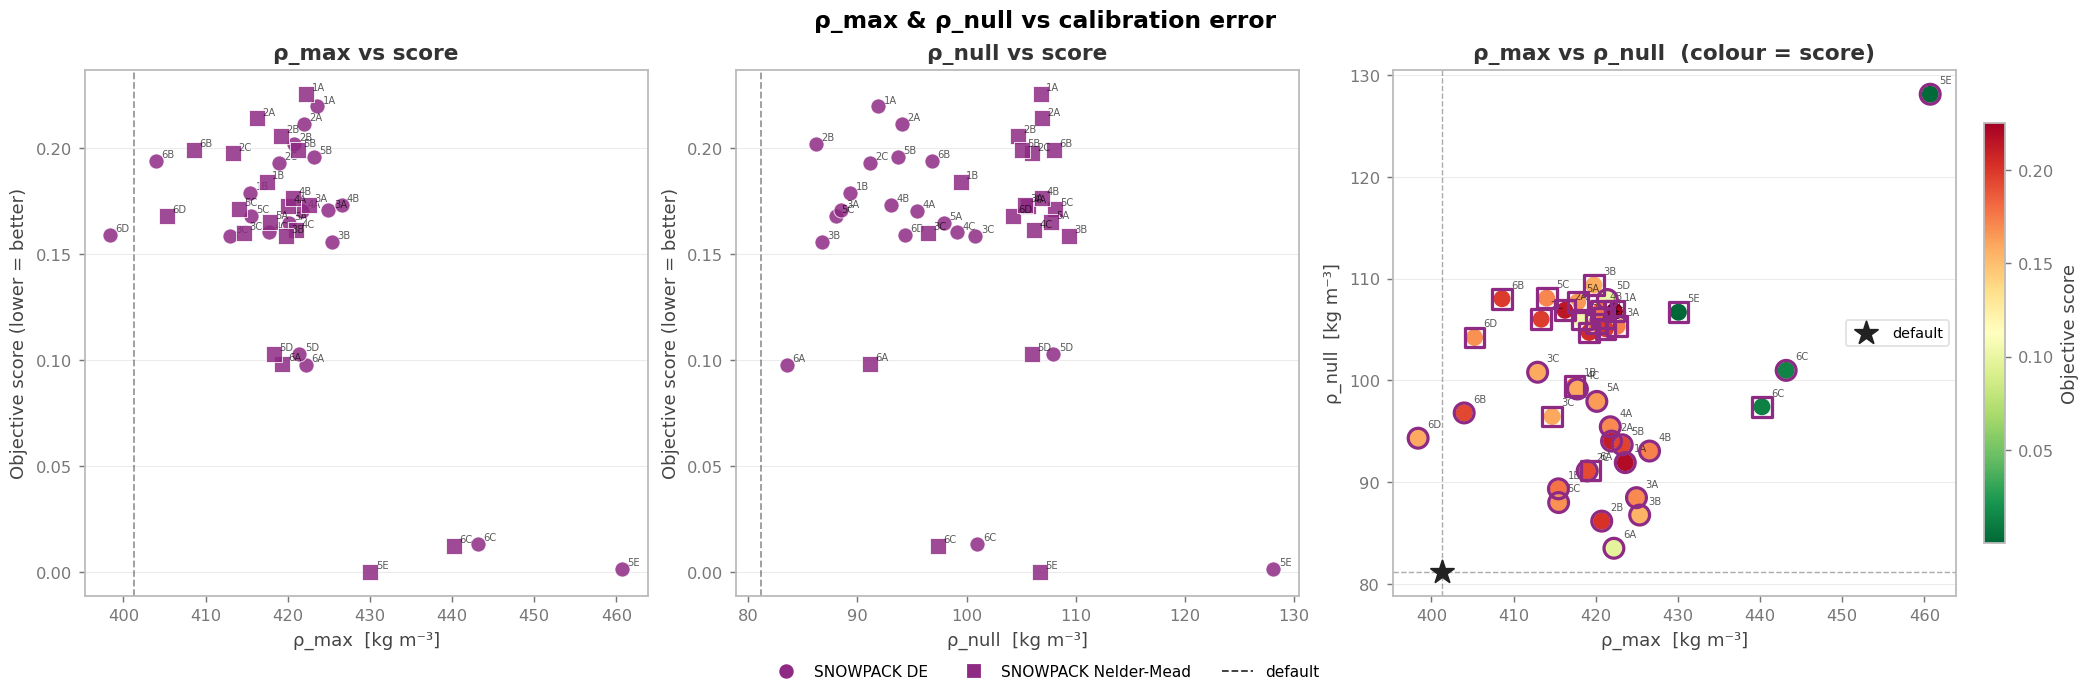

In [34]:
rho_df = df.dropna(subset=['best_value','rho_max','rho_null']).copy()

def ann_label(row):
    """Short annotation: phase name if known, else (SWE/RHO) weights."""
    if row['phase']:
        return row['phase'].split('—')[0].strip()   # e.g. "2A"
    return f"({row['w_SWE_NRMSE']:.1f}/{row['w_RHO_NRMSE']:.1f})"

rho_df['ann'] = rho_df.apply(ann_label, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('ρ_max & ρ_null vs calibration error', fontweight='bold', fontsize=13)

# ── Panel 1: rho_max vs score ─────────────────────────────────────────────────
ax = axes[0]
for ds in DATASETS:
    for alg in ALGS:
        sub = rho_df[(rho_df['dataset']==ds) & (rho_df['algorithm']==alg)]
        if sub.empty: continue
        ax.scatter(sub['rho_max'], sub['best_value'],
                   color=PALETTE.get(ds,'#888'), marker=MARKERS.get(alg,'o'),
                   s=70, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
        for _, r in sub.iterrows():
            ax.annotate(r['ann'], (r['rho_max'], r['best_value']),
                        fontsize=5.5, xytext=(3,2), textcoords='offset points', alpha=0.65)
ax.axvline(401.26, color='#333', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('ρ_max  [kg m⁻³]', fontsize=10)
ax.set_ylabel('Objective score (lower = better)', fontsize=10)
ax.set_title('ρ_max vs score', fontweight='bold')

# ── Panel 2: rho_null vs score ────────────────────────────────────────────────
ax = axes[1]
for ds in DATASETS:
    for alg in ALGS:
        sub = rho_df[(rho_df['dataset']==ds) & (rho_df['algorithm']==alg)]
        if sub.empty: continue
        ax.scatter(sub['rho_null'], sub['best_value'],
                   color=PALETTE.get(ds,'#888'), marker=MARKERS.get(alg,'o'),
                   s=70, alpha=0.85, edgecolors='white', linewidths=0.5, zorder=3)
        for _, r in sub.iterrows():
            ax.annotate(r['ann'], (r['rho_null'], r['best_value']),
                        fontsize=5.5, xytext=(3,2), textcoords='offset points', alpha=0.65)
ax.axvline(81.19, color='#333', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('ρ_null  [kg m⁻³]', fontsize=10)
ax.set_ylabel('Objective score (lower = better)', fontsize=10)
ax.set_title('ρ_null vs score', fontweight='bold')

# ── Panel 3: rho_max vs rho_null, colour = score ──────────────────────────────
ax = axes[2]
sc = ax.scatter(
    rho_df['rho_max'], rho_df['rho_null'],
    c=rho_df['best_value'], cmap='RdYlGn_r',
    s=100, edgecolors='white', linewidths=0.6, zorder=3
)
for ds in DATASETS:
    for alg in ALGS:
        sub = rho_df[(rho_df['dataset']==ds) & (rho_df['algorithm']==alg)]
        if sub.empty: continue
        ax.scatter(sub['rho_max'], sub['rho_null'],
                   marker=MARKERS[alg], facecolors='none',
                   edgecolors=PALETTE.get(ds,'#888'),
                   linewidths=1.8, s=120, zorder=4)
        for _, r in sub.iterrows():
            ax.annotate(r['ann'], (r['rho_max'], r['rho_null']),
                        fontsize=5.5, xytext=(5,6), textcoords='offset points', alpha=0.65)
ax.axvline(401.26, color='#333', lw=0.8, ls='--', alpha=0.4)
ax.axhline(81.19,  color='#333', lw=0.8, ls='--', alpha=0.4)
ax.scatter(401.26, 81.19, marker='*', s=180, color='#222', zorder=5, label='default')
plt.colorbar(sc, ax=ax, label='Objective score', shrink=0.8)
ax.set_xlabel('ρ_max  [kg m⁻³]', fontsize=10)
ax.set_ylabel('ρ_null  [kg m⁻³]', fontsize=10)
ax.set_title('ρ_max vs ρ_null  (colour = score)', fontweight='bold')
ax.legend(fontsize=8)

fig.legend(
    handles=legend_handles(DATASETS, ALGS) + [
        Line2D([0],[0], color='#333', lw=1, ls='--', label='default')
    ],
    loc='lower center', ncol=len(DATASETS)*len(ALGS)+1,
    fontsize=8.5, bbox_to_anchor=(0.5, -0.06), frameon=False
)
plt.savefig(f'{PLOTS_DIR}/07_rho_vs_error.png', bbox_inches='tight')
plt.show()

---
## § 8 — Best Run per Dataset × Algorithm
Which weight combination gives the lowest objective score for each group?

In [35]:
best_idx = df.dropna(subset=['best_value']).groupby(['dataset','algorithm'])['best_value'].idxmin()
best = df.loc[best_idx, ['dataset','algorithm'] + WEIGHT_COLS + ['best_value'] + PAR_COLS].copy()
best = best.sort_values(['dataset','algorithm']).reset_index(drop=True)

# Pretty column names
best.columns = (['Dataset','Algorithm'] +
                [W_LABELS[c] for c in WEIGHT_COLS] +
                ['Score'] +
                [PAR_META[p]['label'] for p in PAR_COLS])

pd.set_option('display.float_format', lambda x: f'{x:.4g}')
pd.set_option('display.max_columns', 30)
display(best.T)

,0,1
Dataset,SNOWPACK,SNOWPACK
Algorithm,DE,Nelder-Mead
w(SWE NRMSE),0,0
w(ρ NRMSE),0,0
w(SWE NBIAS),0.5,0.5
w(ρ NBIAS),0.5,0.5
w(SWE KGE),0,0
w(ρ KGE),0,0
Score,0.001295,1.72e-06
ρ_max,460.7,430.1


---
## § 9 — Score Distribution per Algorithm (Box + Strip)
Quick visual of the score spread across all weight configurations.

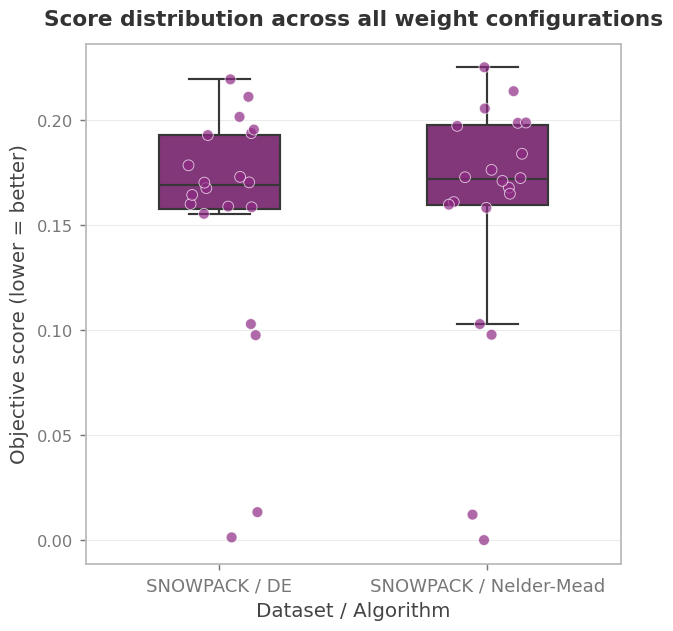

In [36]:
valid = df.dropna(subset=['best_value']).copy()
valid['group'] = valid['dataset'] + ' / ' + valid['algorithm']

fig, ax = plt.subplots(figsize=(max(5, len(valid['group'].unique())*1.5), 5))

group_order = sorted(valid['group'].unique())

# Box plot
sns.boxplot(
    data=valid, x='group', y='best_value',
    order=group_order,
    palette={g: PALETTE.get(g.split(' / ')[0], '#888') for g in group_order},
    width=0.45, fliersize=0,
    ax=ax, linewidth=1.2
)
# Strip plot on top
sns.stripplot(
    data=valid, x='group', y='best_value',
    order=group_order,
    palette={g: PALETTE.get(g.split(' / ')[0], '#888') for g in group_order},
    jitter=0.15, size=6, alpha=0.7,
    edgecolor='white', linewidth=0.5,
    ax=ax, zorder=4
)

ax.set_xlabel('Dataset / Algorithm', fontsize=11)
ax.set_ylabel('Objective score (lower = better)', fontsize=11)
ax.set_title('Score distribution across all weight configurations',
             fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=10)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/09_score_distribution.png', bbox_inches='tight')
plt.show()